## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo.
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import cv2
import keras
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import tensorflow as tf
import kagglehub

from skimage.io import imread
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix
from keras.applications import InceptionV3

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



## 1. Preparación de los datos


In [2]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

TRAIN_PATH = path + "/seg_train/seg_train/"
TEST_PATH = path + "/seg_test/seg_test/"

Using Colab cache for faster access to the 'intel-image-classification' dataset.


In [3]:
clases = sorted(os.listdir(TRAIN_PATH))
clases_names = dict(enumerate(clases))

clases_names

{0: 'buildings',
 1: 'forest',
 2: 'glacier',
 3: 'mountain',
 4: 'sea',
 5: 'street'}

In [4]:
def read_data(path):
    X = []
    y = []
    for i, folder in clases_names.items():  # Recorrer carpetas (con target encoded)
        for file in os.listdir(path + folder):  # Recorrer archivos
            image = imread(path + folder + "/" + file)
            image = cv2.resize(image, (75, 75)) # Tamaño mínimo en InceptionV3

            X.append(image)
            y.append(i)

    return np.array(X), np.array(y)

In [5]:
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)

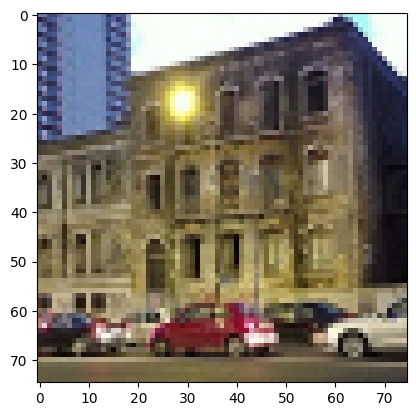

In [6]:
plt.imshow(X_train[6]);

In [7]:
X_train.max(), X_train.min()

(np.uint8(255), np.uint8(0))

Inception espera que los datos estén entre 1 y -1.

In [8]:
X_train = (X_train / 127.5) - 1
X_test = (X_test / 127.5) - 1

In [9]:
X_train.max(), X_train.min()

(np.float64(1.0), np.float64(-1.0))

In [10]:
#  Desordenar los datos por si acaso
X_train, y_train = shuffle(X_train, y_train, random_state=42)

## 2. Transfer Learning

In [11]:
base_model = InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(75, 75, 3))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
base_model.trainable = False

In [13]:
# Capas
x = keras.layers.Flatten()(base_model.output)
x = keras.layers.Dense(2048, activation="relu")(x)
x = keras.layers.Dropout(0.25)(x)
output = keras.layers.Dense(6, activation="softmax")(x)

model = keras.Model(base_model.input, output)

In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 37, 37,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 37, 37,    │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 35, 35,    │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 35, 35,    │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 17, 17,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 17, 17,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 15, 15,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 26,011,430 (99.23 MB)

 Trainable params: 4,208,646 (16.05 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [16]:
early_stopping = keras.callbacks.EarlyStopping(patience=5, restore_best_weights= True)

In [17]:
history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    validation_split=0.2,
    epochs=40,
    callbacks=[early_stopping])

Epoch 1/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.7105 - loss: 0.8463 - val_accuracy: 0.7788 - val_loss: 0.6090
Epoch 2/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.8226 - loss: 0.4741 - val_accuracy: 0.7952 - val_loss: 0.5683
Epoch 3/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.8765 - loss: 0.3434 - val_accuracy: 0.7930 - val_loss: 0.5867
Epoch 4/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.9176 - loss: 0.2391 - val_accuracy: 0.7887 - val_loss: 0.6233
Epoch 5/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9563 - loss: 0.1547 - val_accuracy: 0.7923 - val_loss: 0.6427
Epoch 6/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9727 - loss: 0.1020 - val_accuracy: 0.7781 - val_loss: 0.7052
Epoch 7/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.9863 - loss: 0.0647 - val_accuracy: 0.7870 - val_loss: 0.7219


Veamos los resultados.

In [18]:
model.evaluate(X_test, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 281ms/step - accuracy: 0.8050 - loss: 0.5613


[0.5612959861755371, 0.8050000071525574]

In [19]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred, target_names=clases))

94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 306ms/step
              precision    recall  f1-score   support

   buildings       0.81      0.85      0.83       437
      forest       0.91      0.95      0.93       474
     glacier       0.72      0.75      0.73       553
    mountain       0.72      0.72      0.72       525
         sea       0.82      0.76      0.79       510
      street       0.87      0.83      0.85       501

    accuracy                           0.81      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.81      0.81      0.80      3000



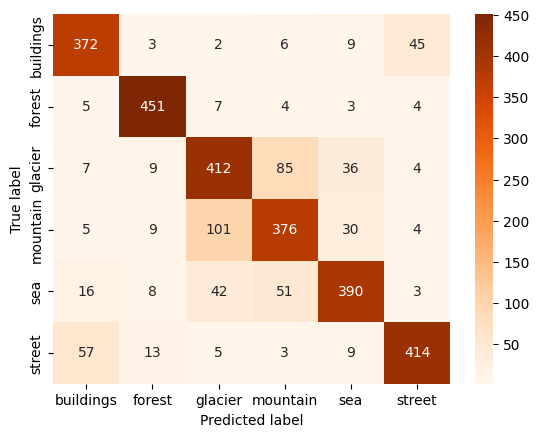

In [20]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Oranges", xticklabels=clases, yticklabels=clases)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

## 3. Fine-Tuning

In [21]:
model_ft = InceptionV3(include_top=False, weights="imagenet", input_shape=(75, 75, 3))
model_ft.trainable = True

In [22]:
x = keras.layers.Flatten()(model_ft.output)
x = keras.layers.Dense(2048, activation="relu")(x)
x = keras.layers.Dropout(0.25)(x)
output = keras.layers.Dense(6, activation="softmax")(x)

model_ft = keras.Model(model_ft.input, output)

In [23]:
model_ft.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [24]:
model_ft.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 37, 37,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 37,    │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 35, 35,    │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 35, 35,    │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 17, 17,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 17, 17,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 15, 15,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 26,011,430 (99.23 MB)

 Trainable params: 25,976,998 (99.09 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [25]:
history_fine = model_ft.fit(
    X_train,
    y_train,
    batch_size=128,
    validation_split=0.2,
    epochs=40,
    callbacks=[early_stopping])

Epoch 1/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 667s 7s/step - accuracy: 0.4589 - loss: 1.5098 - val_accuracy: 0.1706 - val_loss: 4267.6890
Epoch 2/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 606s 7s/step - accuracy: 0.6719 - loss: 0.9577 - val_accuracy: 0.4564 - val_loss: 40.2148
Epoch 3/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 622s 7s/step - accuracy: 0.7527 - loss: 0.8891 - val_accuracy: 0.1649 - val_loss: 33.7286
Epoch 4/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 618s 7s/step - accuracy: 0.7935 - loss: 0.6736 - val_accuracy: 0.3370 - val_loss: 4.7737
Epoch 5/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 615s 7s/step - accuracy: 0.8049 - loss: 0.6195 - val_accuracy: 0.7378 - val_loss: 0.7678


In [26]:
model_ft.evaluate(X_test,y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 30s 316ms/step - accuracy: 0.1707 - loss: 4373.7700


[4373.77001953125, 0.1706666648387909]

In [27]:
y_pred_ft = np.argmax(model_ft.predict(X_test), axis=1)

print(classification_report(y_test, y_pred_ft, target_names=clases))

94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 315ms/step
              precision    recall  f1-score   support

   buildings       0.12      0.00      0.01       437
      forest       0.00      0.00      0.00       474
     glacier       0.00      0.00      0.00       553
    mountain       0.00      0.00      0.00       525
         sea       0.17      1.00      0.29       510
      street       0.00      0.00      0.00       501

    accuracy                           0.17      3000
   macro avg       0.05      0.17      0.05      3000
weighted avg       0.05      0.17      0.05      3000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


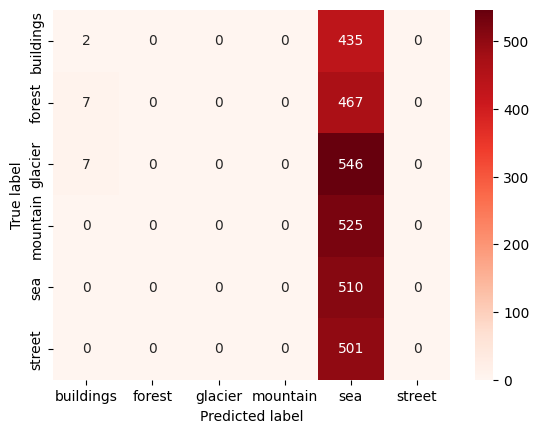

In [28]:
sns.heatmap(confusion_matrix(y_test, y_pred_ft), annot=True, fmt="d", cmap="Reds", xticklabels=clases, yticklabels=clases)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

Algo ha ido mal con el modelo de fine-tuning porque le gusta demasiado el mar. El modelo de TL es bastante bueno, acertando con un 80% de las fotos del test, que claramente es mejor que la fijación por el mar que tiene el mdoelo de fine-tuning.

